# 💰 Sesión 9 — De la prima pura a la prima de tarifa: ajuste por inflación
## Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · UNAM

---

**Semana 4 · Tema 2 (Cálculo de primas)** · **Herramienta:** Python

---

> **Objetivo:** ya tienen la prima pura de su ramo (Tema 1). Aquí ven el **primer ajuste** para
> llegar al precio: llevar los montos históricos a **valor de hoy** (inflación), medir cómo eso
> **mueve la prima pura**, y asomarse a la **devaluación**. Y sobre todo: **documentar cada supuesto**,
> porque así se construye una nota técnica.
>
> 🟢 Las celdas normales las corremos juntos. **✏️ Las de Ejercicio las completas tú.**

## Contenido
1. [Entorno](#1)
2. [El problema: montos de años distintos](#2)
3. [Ajuste por inflación con un índice](#3)
4. [Efecto en la severidad y en la prima pura](#4)
5. [Un vistazo a la devaluación](#5)
6. [Documentar los supuestos (nota técnica)](#6)
7. [Cierre](#7)

---

---
<a id='1'></a>
## 1. Entorno

In [58]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
np.random.seed(9); plt.rcParams["figure.figsize"] = (8, 3.6)
print("✓ listo")

✓ listo


---
<a id='2'></a>
## 2. El problema: montos de años distintos

Una cartera real tiene siniestros de **varios años**, cada uno en **pesos de su año**. Si los mezclas
tal cual, los años viejos "valen menos" y **subestimas** el costo actual. Simulamos una tabla de
siniestros con su año de ocurrencia.

In [77]:
# ─── Siniestros históricos (año de ocurrencia + monto nominal) ─────────────
anios = np.arange(2019, 2025)
n_por_anio = 400
# la severidad "real" crece con la inflación; aquí la generamos en pesos de cada año
infl_real = {2019:1.00, 2020:1.034, 2021:1.108, 2022:1.196, 2023:1.260, 2024:1.316}
filas = []
for a in anios:
    montos = np.random.lognormal(mean=np.log(40000*infl_real[a]), sigma=0.9, size=n_por_anio)
    filas.append(pd.DataFrame({"anio": a, "monto_nominal": montos.round(0)}))
sin = pd.concat(filas, ignore_index=True)

print(sin.groupby("anio")["monto_nominal"].mean().round(0).to_string())
print(f"\nSeveridad media SIN ajustar (todos los años juntos): {sin.monto_nominal.mean():,.0f}")
print("→ mezcla pesos de 2019 con pesos de 2024: no es comparable.")

anio
2019    59488.0
2020    66976.0
2021    63299.0
2022    68882.0
2023    85764.0
2024    74131.0

Severidad media SIN ajustar (todos los años juntos): 69,757
→ mezcla pesos de 2019 con pesos de 2024: no es comparable.


---
<a id='3'></a>
## 3. Ajuste por inflación con un índice

Cada monto se lleva a **valor de hoy** multiplicándolo por el cociente de índices:

$$X^{\mathrm{ajust}}_t = X_t \times \frac{I_{\mathrm{hoy}}}{I_t}$$

Usamos un índice acumulado (aquí ilustrativo; en la práctica sería el INPC o uno propio del ramo).

      nominal  ajustado
anio                   
2019  59488.0   78286.0
2020  66976.0   85243.0
2021  63299.0   75182.0
2022  68882.0   75793.0
2023  85764.0   89576.0
2024  74131.0   74131.0


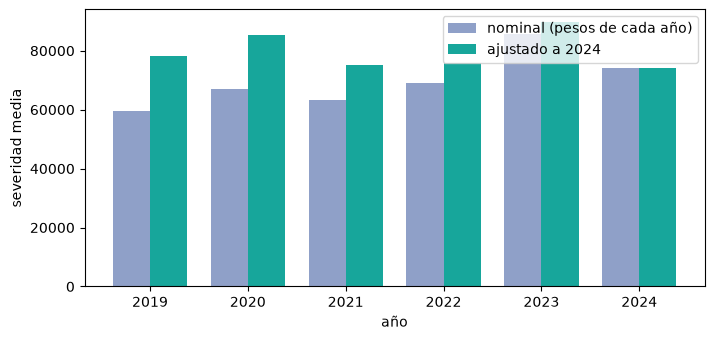

Tras ajustar, los años viejos suben a valor de hoy y se vuelven comparables.


In [78]:
# ─── Llevar todo a valor de 2024 ───────────────────────────────────────────
indice = {2019:1.00, 2020:1.034, 2021:1.108, 2022:1.196, 2023:1.260, 2024:1.316}
I_hoy = indice[2024]
sin["factor"] = sin["anio"].map(lambda a: I_hoy / indice[a])
sin["monto_ajustado"] = (sin["monto_nominal"] * sin["factor"]).round(0)

comp = sin.groupby("anio").agg(nominal=("monto_nominal","mean"),
                               ajustado=("monto_ajustado","mean")).round(0)
print(comp.to_string())
w=0.38
plt.bar(anios-w/2, comp["nominal"], width=w, label="nominal (pesos de cada año)", color="#8FA0C8")
plt.bar(anios+w/2, comp["ajustado"], width=w, label="ajustado a 2024", color="#17A69B")
plt.xlabel("año"); plt.ylabel("severidad media"); plt.legend(); plt.show()
print("Tras ajustar, los años viejos suben a valor de hoy y se vuelven comparables.")

### ✏️ Ejercicio 1 — el factor de un año

1. ¿Cuál es el factor de ajuste de **2020** a valor de 2024?
2. Un siniestro de 2020 por \$30,000 nominales, ¿cuánto vale en pesos de 2024?

In [80]:
# Ejercicio 1
factor_2020 = I_hoy / indice[2020]
siniestro_2020 = 30000
valor_2024 = siniestro_2020 * factor_2020

print(f"Factor de ajuste de 2020 a 2024: {factor_2020:.4f}")
print(f"Un siniestro de $30,000 en 2020 equivale a ${valor_2024:,.2f} en pesos de 2024")

Factor de ajuste de 2020 a 2024: 1.2727
Un siniestro de $30,000 en 2020 equivale a $38,181.82 en pesos de 2024


---
<a id='4'></a>
## 4. Efecto en la severidad y en la prima pura

La prima pura es frecuencia × severidad. La frecuencia no cambia con la inflación, pero **la severidad
sí**: comparamos la prima pura con y sin ajuste.

In [81]:
# ─── Prima pura: sin ajustar vs. ajustada ──────────────────────────────────
frecuencia = 0.30                                   # siniestros por año-póliza (dato del Tema 1)
EX_sin = sin.monto_nominal.mean()
EX_aj  = sin.monto_ajustado.mean()
pp_sin = frecuencia * EX_sin
pp_aj  = frecuencia * EX_aj

print(f"Severidad media  sin ajustar : {EX_sin:,.0f}")
print(f"Severidad media  ajustada    : {EX_aj:,.0f}")
print(f"\nPrima pura sin ajustar : {pp_sin:,.0f} por año-póliza")
print(f"Prima pura ajustada    : {pp_aj:,.0f} por año-póliza")
print(f"\nSubestimación si NO ajustas: {1 - pp_sin/pp_aj:.1%}")
print("Ignorar la inflación deja la prima corta — y con ella, insuficiencia de reservas.")

Severidad media  sin ajustar : 69,757
Severidad media  ajustada    : 79,702

Prima pura sin ajustar : 20,927 por año-póliza
Prima pura ajustada    : 23,911 por año-póliza

Subestimación si NO ajustas: 12.5%
Ignorar la inflación deja la prima corta — y con ella, insuficiencia de reservas.


### ✏️ Ejercicio 2 — el costo de no ajustar

1. Recalcula la prima pura ajustada suponiendo una **frecuencia de 0.45** en vez de 0.30.
2. ¿La *subestimación relativa* (%) por no ajustar cambia con la frecuencia? ¿Por qué?

In [82]:
#1.
frecuencia_nueva = 0.45

pp_sin_045 = frecuencia_nueva * EX_sin
pp_aj_045  = frecuencia_nueva * EX_aj

#2.
subestimacion_045 = (1 - pp_sin_045 / pp_aj_045) * 100

print(f"Prima pura sin ajustar : {pp_sin_045:,.0f} por año-póliza")
print(f"Prima pura ajustada    : {pp_aj_045:,.0f} por año-póliza")
print(f"Subestimación relativa : {subestimacion_045:.1f}%")
print("\nLa subestimación relativa no cambia con la frecuencia,")
print("porque la frecuencia multiplica tanto a la prima sin ajustar como a la ajustada y se cancela al calcular la proporción.")

Prima pura sin ajustar : 31,391 por año-póliza
Prima pura ajustada    : 35,866 por año-póliza
Subestimación relativa : 12.5%

La subestimación relativa no cambia con la frecuencia,
porque la frecuencia multiplica tanto a la prima sin ajustar como a la ajustada y se cancela al calcular la proporción.


---
<a id='5'></a>
## 5. Un vistazo a la devaluación

En ramos con exposición en **dólares** (marítimo, transportes), la suma asegurada y el siniestro se
convierten a pesos con el tipo de cambio:

$$SA_{\mathrm{MXN}} = SA_{\mathrm{USD}} \times TC$$

Una devaluación (TC más alto) **encarece** el costo en pesos.

In [84]:
# ─── Efecto del tipo de cambio en una cartera en USD ───────────────────────
sa_usd = 100_000                    # suma asegurada en dólares
for tc in [17.0, 18.5, 20.0]:
    print(f"TC = {tc:>5.1f}  →  suma asegurada en pesos = {sa_usd*tc:,.0f}")
print("\nEl mismo bien 'cuesta' más pesos si el peso se devalúa: la prima en pesos debe reflejarlo.")

TC =  17.0  →  suma asegurada en pesos = 1,700,000
TC =  18.5  →  suma asegurada en pesos = 1,850,000
TC =  20.0  →  suma asegurada en pesos = 2,000,000

El mismo bien 'cuesta' más pesos si el peso se devalúa: la prima en pesos debe reflejarlo.


### ✏️ Ejercicio 3 — sensibilidad al tipo de cambio

1. Con `sa_usd = 250,000`, calcula la suma asegurada en pesos para TC = 17 y TC = 21.
2. ¿En qué porcentaje sube el costo en pesos al pasar de 17 a 21?

In [85]:
# Ejercicio 3 — sensibilidad al tipo de cambio

sa_usd = 250000

tc_17 = 17
tc_21 = 21

sa_mxn_17 = sa_usd * tc_17
sa_mxn_21 = sa_usd * tc_21

aumento_porcentual = (sa_mxn_21 / sa_mxn_17 - 1) * 100

print(f"Suma asegurada con TC = 17: ${sa_mxn_17:,.2f} MXN")
print(f"Suma asegurada con TC = 21: ${sa_mxn_21:,.2f} MXN")
print(f"El costo sube: {aumento_porcentual:.2f}%")

Suma asegurada con TC = 17: $4,250,000.00 MXN
Suma asegurada con TC = 21: $5,250,000.00 MXN
El costo sube: 23.53%


---
<a id='6'></a>
## 6. Documentar los supuestos (nota técnica)

Cada ajuste que hicimos es un **supuesto** que la nota técnica debe justificar. Dejamos el registro
explícito — esto es parte de la entrega, no un adorno.

In [108]:
# ─── Registro de supuestos (así se documenta) ──────────────────────────────
supuestos = pd.DataFrame([
    {"supuesto": "Índice de inflación", "valor": "acumulado 2019–2024 (ilustrativo; usar INPC)", "fuente": "INEGI / propio del ramo"},
    {"supuesto": "Año base de ajuste",  "valor": "2024 (valor de hoy)",                         "fuente": "criterio del actuario"},
    {"supuesto": "Frecuencia",          "valor": f"{frecuencia:.2f} sin/año-póliza",             "fuente": "Tema 1 (ajuste propio)"},
    {"supuesto": "Tipo de cambio",      "valor": "escenario 17–20 MXN/USD",                     "fuente": "Banxico"},
])
print(supuestos.to_string(index=False))
print("\nRegla: un número sin fuente y sin justificación NO es válido ante la CNSF.")

           supuesto                                        valor                  fuente
Índice de inflación acumulado 2019–2024 (ilustrativo; usar INPC) INEGI / propio del ramo
 Año base de ajuste                          2024 (valor de hoy)   criterio del actuario
         Frecuencia                          0.30 sin/año-póliza  Tema 1 (ajuste propio)
     Tipo de cambio                      escenario 17–20 MXN/USD                 Banxico

Regla: un número sin fuente y sin justificación NO es válido ante la CNSF.


### ✏️ Ejercicio 4 — tu tabla de supuestos

Para tu ramo, agrega **una fila** a la tabla de supuestos con un ajuste que aplique a tu cartera
(por ejemplo, depreciación si aseguras bienes, o el índice que usarías), con su **valor** y su
**fuente**.

In [109]:

supuestos = pd.DataFrame([
    {"supuesto": "Índice de inflación", "valor": "acumulado 2019–2024 (ilustrativo; usar INPC)", "fuente": "INEGI / propio del ramo"},
    {"supuesto": "Año base de ajuste",  "valor": "2024 (valor de hoy)",                         "fuente": "criterio del actuario"},
    {"supuesto": "Frecuencia",          "valor": f"{frecuencia:.2f} sin/año-póliza",             "fuente": "Tema 1 (ajuste propio)"},
    {"supuesto": "Tipo de cambio",      "valor": "escenario 17–20 MXN/USD",                     "fuente": "Banxico"},
    {"supuesto": "Temporada de Ciclones", "valor": "+20% en prima base (Junio-Noviembre)", "fuente": "Criterio aseguradora (Exp. de la Cedente) / Parámetros del SMN"}
])

print(supuestos.to_string(index=False))

             supuesto                                        valor                                                         fuente
  Índice de inflación acumulado 2019–2024 (ilustrativo; usar INPC)                                        INEGI / propio del ramo
   Año base de ajuste                          2024 (valor de hoy)                                          criterio del actuario
           Frecuencia                          0.30 sin/año-póliza                                         Tema 1 (ajuste propio)
       Tipo de cambio                      escenario 17–20 MXN/USD                                                        Banxico
Temporada de Ciclones         +20% en prima base (Junio-Noviembre) Criterio aseguradora (Exp. de la Cedente) / Parámetros del SMN


##### **Nuevo Supuesto: Temporada de Ciclones**

* **Valor:** `+20% en prima base (Junio-Noviembre)`

* **Fuente:** `Criterio aseguradora (Exp. de la Cedente) / Parámetros del SMN` <br>
    Exp: Siniestralidad histórica, historial de pérdidas acumuladas y las políticas de suscripción de la compañía aseguradora. <br> El SMN Define la temporalidad oficial de la temporada de ciclones en México (junio a noviembre).

---
<a id='7'></a>
## 7. Cierre

- La **inflación** lleva los montos históricos a valor de hoy; sin ese ajuste, la prima pura queda **corta**.
- La **devaluación** y la **depreciación** ajustan el valor del bien y del siniestro en el tiempo.
- Todo esto es **prima pura ajustada**, todavía **NO el precio**: faltan gastos, margen, IBNR y reaseguro.
- Cada ajuste es un **supuesto documentado y validado**: así se construye la nota técnica.

**Próxima sesión:** los recargos — gastos, comisiones, márgenes técnicos y la prima comercial.

---
*Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · Semana 4 · Sesión 9*